[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/09_data_aggregation/09_1_Meet_Gapminder.ipynb)

# 09.1: Meet Gapminder

In module 06 you learned to group a DataFrame by a single column and compute a mean. That one-line pattern, `groupby(col)[col].mean()`, gets you surprisingly far. But it leaves a lot of questions unanswered: what if you want five summary statistics at once instead of one? What if you need to group by two variables simultaneously? What if you want the group result added back to every individual row rather than collapsed into a summary?

This module answers all of those questions. The dataset we use throughout is Gapminder, a curated collection of country-level data assembled by the Gapminder Foundation to track human development over time.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

url = "https://raw.githubusercontent.com/jennybc/gapminder/main/inst/extdata/gapminder.tsv"
df = pd.read_csv(url, sep="\t")
df.to_parquet("gapminder.parquet", index=False)
df.head()

## What this dataset contains

Before grouping anything, you need to know what each row represents. Run `df.info()` to see the column names, their types, and whether any values are missing. For this dataset, the shape itself is a clue: if you know there are 142 countries and 12 time points, you can already predict how many rows a clean panel dataset should have.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   continent  1704 non-null   str    
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), str(2)
memory usage: 80.0 KB


Six columns, 1,704 rows, no missing values. The columns are:

- `country`: the country name (142 unique countries)
- `continent`: one of Africa, Americas, Asia, Europe, Oceania
- `year`: one of 12 values from 1952 to 2007 in 5-year steps
- `lifeExp`: life expectancy at birth, in years
- `pop`: total population
- `gdpPercap`: GDP per capita in inflation-adjusted US dollars

This is **panel data**: each country appears once per year, so the dataset has 142 countries × 12 years = 1,704 rows. The unique identifier for each row is the `(country, year)` pair.

In [3]:
print("Countries:", df["country"].nunique())
print("Continents:", df["continent"].value_counts().to_dict())
print("Years:", sorted(df["year"].unique()))

Countries: 142
Continents: {'Africa': 624, 'Asia': 396, 'Europe': 360, 'Americas': 300, 'Oceania': 24}
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]


Africa has the most countries (52), followed by Asia (33) and the Americas (25). Europe has 30. Oceania has only 2 (Australia and New Zealand). Oceania summaries represent two countries, not a whole region in the same sense as the others, and that will matter when we compare continent-level statistics.

The 12 years from 1952 to 2007 give us a 55-year window that spans decolonization, the Cold War, the AIDS epidemic in sub-Saharan Africa, and rapid economic development in East Asia.

## A first look at the numerics

The three numeric columns measure very different things on very different scales. Before grouping by anything, look at the ranges: knowing the minimum and maximum of each column tells you whether extreme values exist and whether any aggregation function you compute will be pulled by outliers.

In [4]:
df[["lifeExp", "pop", "gdpPercap"]].describe().round(1)

,lifeExp,pop,gdpPercap
count,1704.0,1.704000e+03,1704.0
mean,59.5,2.960121e+07,7215.3
std,12.9,1.061579e+08,9857.5
min,23.6,6.001100e+04,241.2
25%,48.2,2.793664e+06,1202.1
50%,60.7,7.023596e+06,3531.8
75%,70.8,1.958522e+07,9325.5
max,82.6,1.318683e+09,113523.1


Three things stand out. First, life expectancy ranges from 23.6 years (the minimum, reflecting early-1950s conditions in some African countries) to 82.6 years, a span of nearly 60 years within the same dataset. Second, population ranges from 60,000 to 1.3 billion, a range of four orders of magnitude that will matter if we ever weight aggregations by population. Third, GDP per capita has a mean of $7,215 but a median of only $3,532, confirming the right skew visible in the large standard deviation: a handful of wealthy countries pull the average up considerably.

These global statistics are starting points. The interesting questions are always about groups.

## A quick review of single-key groupby

You already know how to answer a question like "what is the mean life expectancy in each continent?" using the groupby you learned in module 06. Let's run it once to confirm the baseline and establish what the rest of this module builds on.

In [5]:
# Filter to 2007 for a snapshot comparison
df2007 = df[df["year"] == 2007].copy()

df2007.groupby("continent")["lifeExp"].mean().round(1).sort_values(ascending=False)

continent
Oceania     80.7
Europe      77.6
Americas    73.6
Asia        70.7
Africa      54.8
Name: lifeExp, dtype: float64

In 2007, Oceania leads with a mean life expectancy of about 80 years, followed by Europe. Africa trails significantly. This one-liner answers the question, but it raises more: how much variation is there within each continent? How did these numbers change over time? How does each individual country compare to its continental peers?

None of those follow-up questions can be answered with a single-key groupby and a single aggregation function. The rest of this module introduces the tools that can.

## What the data looks like overall

The three numeric columns have very different distributions. Visualizing them before computing any grouped statistics helps you know what to expect and spot anything surprising. A country with a 1952-era life expectancy of 23 years is a real data point, not a data error, but it will look like an outlier on a histogram until you understand the historical context.

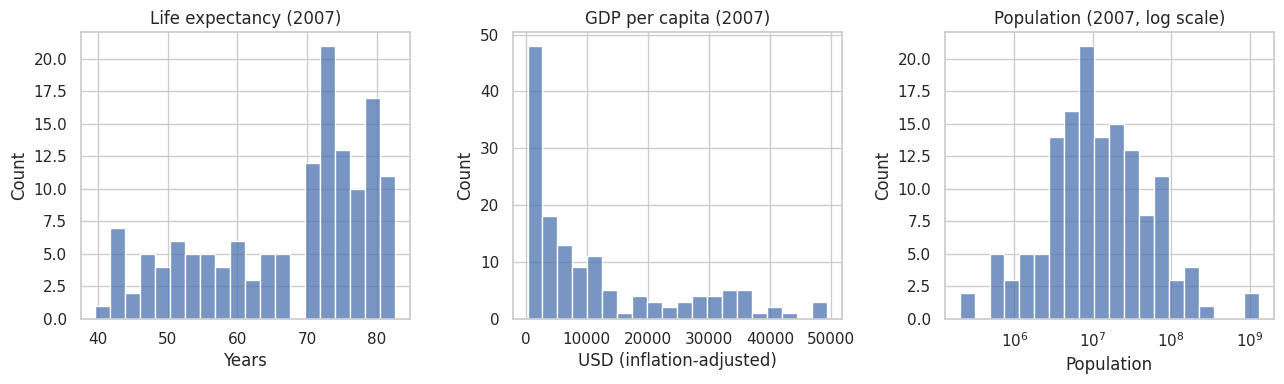

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

sns.histplot(data=df2007, x="lifeExp", bins=20, ax=axes[0])
axes[0].set_title("Life expectancy (2007)")
axes[0].set_xlabel("Years")

sns.histplot(data=df2007, x="gdpPercap", bins=20, ax=axes[1])
axes[1].set_title("GDP per capita (2007)")
axes[1].set_xlabel("USD (inflation-adjusted)")

sns.histplot(data=df2007, x="pop", bins=20, log_scale=True, ax=axes[2])
axes[2].set_title("Population (2007, log scale)")
axes[2].set_xlabel("Population")

plt.tight_layout()

Life expectancy has a bimodal shape in 2007: a cluster of countries in the 40s and 50s (mostly sub-Saharan Africa, many affected by the AIDS epidemic) and a larger cluster in the 70s. GDP per capita is strongly right-skewed: most countries are clustered at low values, with a long tail of wealthy nations. Population requires a log scale to be legible at all, spanning from tiny island nations to China and India.

These distributions confirm that aggregating across all countries without grouping by continent or year would produce statistics that do not describe any country well. Grouping is not just a convenience; it is necessary for the statistics to be meaningful.

## What's next

The single-key groupby you already know answers one question at a time about one grouping variable. Notebook 09.2 introduces multi-key groupby: grouping by continent AND year simultaneously to track how each continent has changed over time. That requires understanding a new data structure, the MultiIndex, and the `unstack()` method for reshaping it.